# Fitbit Marketing Analysis  

This notebook generates visualization supporting the SQL-based marketing performance analysis.
The objective is to explore engagement, revenue efficiency, geographic variation, and time-based trends using aggregated query outputs.

In [ ]:
## Imports and Setup

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

## 1. Campaign Overview  

Visualizing overall performance and funnel progression.

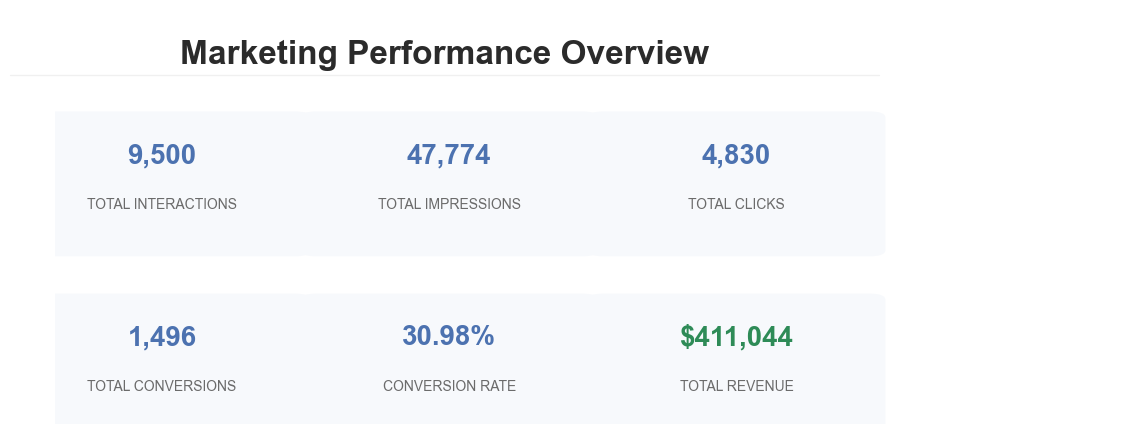

In [131]:
sns.set_theme(style="white")

metrics = {
    "Total Interactions": "9,500",
    "Total Impressions": "47,774",
    "Total Clicks": "4,830",
    "Total Conversions": "1,496",
    "Conversion Rate": "30.98%",
    "Total Revenue": "$411,044"
}

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.axis("off")

# Color system (same vibe as funnel)
primary = "#4C72B0"
text_dark = "#2B2B2B"
text_muted = "#6B6B6B"
card_bg = "#F7F9FC"

x_positions = [0.1, 0.37, 0.64]
y_positions = [0.58, 0.14]

card_width = 0.25
card_height = 0.32

i = 0
for y in y_positions:
    for x in x_positions:
        label = list(metrics.keys())[i]
        value = list(metrics.values())[i]

        # Card background
        rect = patches.FancyBboxPatch(
            (x - card_width/2, y - card_height/2),
            card_width,
            card_height,
            boxstyle="round,pad=0.015",
            linewidth=0,
            facecolor=card_bg
        )
        ax.add_patch(rect)

        value_color = "#2E8B57" if "Revenue" in label else primary
        
        ax.text(x, y + 0.05,
                value,
                fontsize=20,
                fontweight="bold",
                ha="center",
                color=value_color)


        # Label (muted)
        ax.text(x, y - 0.06,
                label.upper(),
                fontsize=10,
                ha="center",
                color=text_muted)
        
        i += 1

# --- Compute grid bounds ---
left_bound = min(x_positions) - card_width / 2
right_bound = max(x_positions) + card_width / 2
grid_center = (left_bound + right_bound) / 2

# --- Adjust vertical positions ---
title_y = 0.91-0.05
divider_y = 0.865-0.05

# --- Title ---
fig.text(grid_center, title_y,
         "Marketing Performance Overview",
         ha="center",
         va="center",
         fontsize=24,
         fontweight="bold",
         color=text_dark)

# --- Divider ---
fig.lines.append(
    plt.Line2D([left_bound, right_bound],
               [divider_y, divider_y],
               transform=fig.transFigure,
               color="#000000",
               alpha=0.06,
               linewidth=1)
)


plt.tight_layout()
plt.show()

fig.savefig("../figures/marketing_performance_overview.png", dpi=300, bbox_inches="tight")

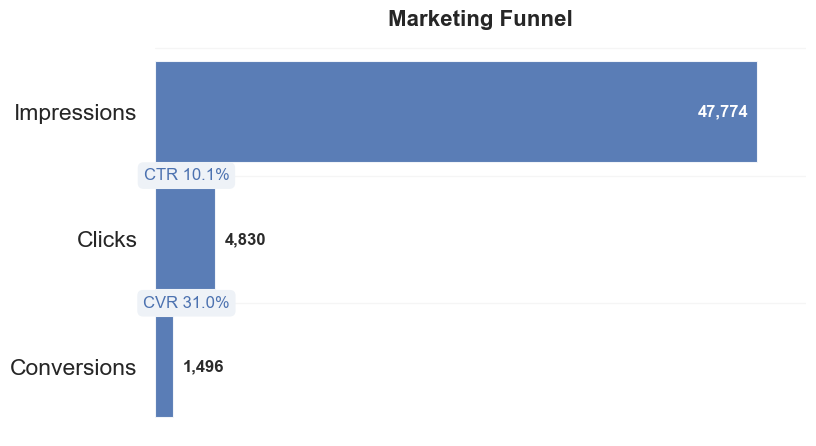

In [127]:
sns.set_theme(style="white", context="talk")

stages = ["Impressions", "Clicks", "Conversions"]
values = np.array([47774, 4830, 1496])

fig, ax = plt.subplots(figsize=(8.5, 4.8))

# Portfolio-friendly palette
bar_color = "#4C72B0"
pill_bg = "#EEF2F7"
text_dark = "#2B2B2B"

bars = ax.barh(stages, values, color=bar_color, alpha=0.92)

# Funnel feel
ax.invert_yaxis()

# Clean axes
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
sns.despine(left=True, bottom=True)

max_value = values.max()
ax.set_xlim(0, max_value * 1.08)

# Subtle row separators (nice for portfolio polish)
for y in range(len(stages)):
    ax.axhline(y - 0.5, color="#000000", alpha=0.04, linewidth=1, zorder=0)

# Value labels with smart placement + contrast
for bar in bars:
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    inside = width > max_value * 0.18  # threshold; tweak to taste

    if inside:
        ax.text(width * 0.985, y, f"{int(width):,}",
                va='center', ha='right',
                color="white", fontsize=12, fontweight="bold")
    else:
        ax.text(width + max_value * 0.015, y, f"{int(width):,}",
                va='center', ha='left',
                color=text_dark, fontsize=12, fontweight="bold")

# Rates (pills)
ctr = values[1] / values[0]
cvr = values[2] / values[1]

ax.text(values[1] * 0.52, 0.5, f"CTR {ctr:.1%}",
        ha="center", va="center",
        fontsize=12, fontweight="medium",
        color=bar_color,
        bbox=dict(boxstyle="round,pad=0.35", facecolor=pill_bg, edgecolor="none"))

ax.text(values[1] * 0.52, 1.5, f"CVR {cvr:.1%}",
        ha="center", va="center",
        fontsize=12, fontweight="medium",
        color=bar_color,
        bbox=dict(boxstyle="round,pad=0.35", facecolor=pill_bg, edgecolor="none"))

# Title
ax.set_title("Marketing Funnel", fontsize=16, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

fig.savefig("../figures/marketing_funnel.png", dpi=300, bbox_inches="tight")


> Click-to-conversion rate is particularly strong, suggesting effective targeting. 

## 2. Engagement by Platform  

Visualizing ad engagement by platform.

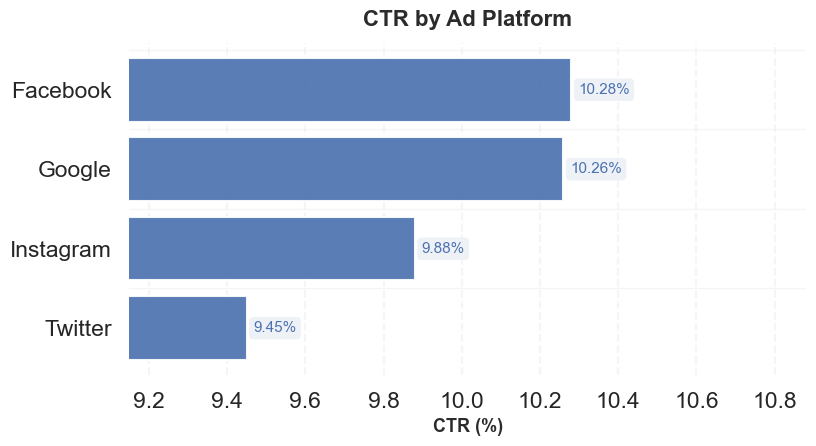

In [98]:
# --- Load + sort so highest CTR appears on top ---
engagement = pd.read_csv("../results/engagement_by_platform.csv")
engagement = engagement.sort_values("ctr_percent", ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 4.8))

# --- Style system (match your other figures) ---
primary = "#4C72B0"
text_dark = "#2B2B2B"
text_muted = "#6B6B6B"
pill_bg = "#EEF2F7"

# --- Bars (single sleek color) ---
bars = ax.barh(
    engagement["adplatform"],
    engagement["ctr_percent"],
    color=primary,
    alpha=0.92
)

# Put best performer at top
ax.invert_yaxis()

# --- Clean axes ---
ax.set_xlabel("CTR (%)", fontweight="bold", fontsize=13, color=text_dark)
ax.set_ylabel("")
sns.despine(ax=ax, left=True, bottom=True)

# Subtle x-grid (lighter than before)
ax.grid(axis="x", linestyle="--", alpha=0.18)

# Add subtle row separators (portfolio polish)
for y in range(len(engagement)):
    ax.axhline(y - 0.5, color="#000000", alpha=0.04, linewidth=1, zorder=0)

# --- Limits with a bit of breathing room (avoid hardcoding if possible) ---
xmin = max(0, engagement["ctr_percent"].min() - 0.3)
xmax = engagement["ctr_percent"].max() + 0.6
ax.set_xlim(xmin, xmax)

# --- Value labels as "pills" ---
for bar in bars:
    val = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    ax.text(val + (xmax - xmin) * 0.01,
            y,
            f"{val:.2f}%",
            va="center",
            ha="left",
            fontsize=11,
            color=primary,
            bbox=dict(boxstyle="round,pad=0.28", facecolor=pill_bg, edgecolor="none"))

# --- Title (consistent vibe) ---
ax.set_title("CTR by Ad Platform", fontsize=16, fontweight="bold", pad=12, color=text_dark)

plt.tight_layout()
plt.show()

fig.savefig("../figures/ctr_by_platform.png", dpi=300, bbox_inches="tight")



> Instagram and Twitter have slightly lower CTR, suggesting potential opportunity for creative or targeting optimization.

## 3. Revenue / ROI by Product Category

Visualizing revenue volume and revenue efficiency across products.

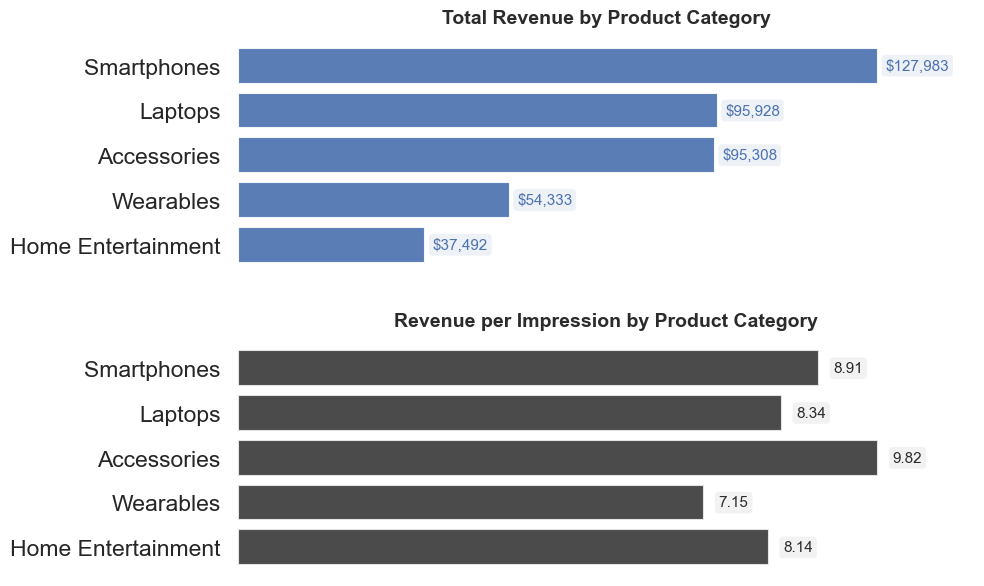

In [126]:
# --- Load + sort so highest total revenue appears on top ---
df = pd.read_csv("../results/roi_by_product_category.csv")
df = df.sort_values("total_revenue", ascending=False)

# --- Style system ---
primary = "#4C72B0"
dark = "#2B2B2B"
text_dark = "#2B2B2B"
text_muted = "#6B6B6B"
pill_bg = "#EEF2F7"

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9.5, 7),
    sharey=True
)

# ===============================
# Chart 1 — Total Revenue
# ===============================

bars1 = ax1.barh(
    df["productcategory"],
    df["total_revenue"],
    color=primary,
    alpha=0.92
)

ax1.invert_yaxis()
sns.despine(ax=ax1, left=True, bottom=True)

ax1.set_xticks([])
ax1.set_xlabel("")
ax1.set_ylabel("")

xmax1 = df["total_revenue"].max() * 1.15
ax1.set_xlim(0, xmax1)

for bar, val in zip(bars1, df["total_revenue"]):
    y = bar.get_y() + bar.get_height()/2
    ax1.text(val + xmax1 * 0.01, y, f"${val:,.0f}",
             va="center", ha="left",
             fontsize=11,
             color=primary,
             bbox=dict(boxstyle="round,pad=0.25",
                       facecolor=pill_bg,
                       edgecolor="none"))

ax1.set_title("Total Revenue by Product Category",
              fontsize=14,
              fontweight="bold",
              pad=10,
              color=text_dark)

# ===============================
# Chart 2 — Revenue per Impression
# ===============================

bars2 = ax2.barh(
    df["productcategory"],
    df["revenue_per_impression"],
    color=dark,
    alpha=0.85
)

sns.despine(ax=ax2, left=True, bottom=True)

ax2.set_xticks([])
ax2.set_xlabel("")
ax2.set_ylabel("")

xmax2 = df["revenue_per_impression"].max() * 1.15
ax2.set_xlim(0, xmax2)

for bar, val in zip(bars2, df["revenue_per_impression"]):
    y = bar.get_y() + bar.get_height()/2
    ax2.text(val + xmax2 * 0.02, y, f"{val:.2f}",
             va="center", ha="left",
             fontsize=11,
             color=dark,
             bbox=dict(boxstyle="round,pad=0.25",
                       facecolor="#F2F2F2",
                       edgecolor="none"))

ax2.set_title("Revenue per Impression by Product Category",
              fontsize=14,
              fontweight="bold",
              pad=10,
              color=text_dark)

# Tighten vertical spacing so they feel unified
plt.subplots_adjust(hspace=0.28)

plt.show()

# Optional save:
fig.savefig("../figures/revenue_and_rpi_by_category.png", dpi=300, bbox_inches="tight")


> The relatively small efficiency gap across products suggests a balanced portfolio.

## 4. Revenue / ROI by Country

Visualizing revenue volume and revenue efficiency across countries.

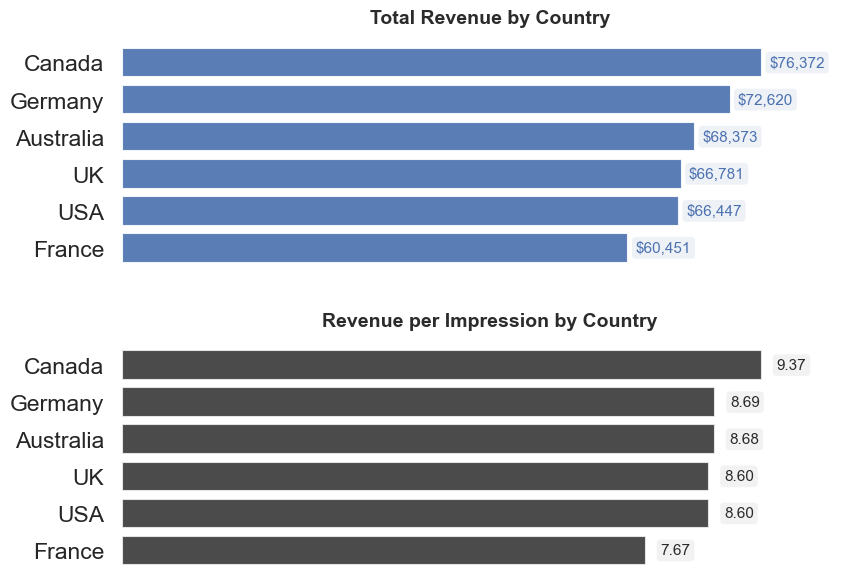

In [2]:
# --- Load + sort so highest total revenue appears on top ---
df = pd.read_csv("../results/revenue_by_country.csv")
df = df.sort_values("total_revenue", ascending=False)

# --- Style system ---
primary = "#4C72B0"
dark = "#2B2B2B"
text_dark = "#2B2B2B"
text_muted = "#6B6B6B"
pill_bg = "#EEF2F7"

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    figsize=(9.5, 7),
    sharey=True
)

# ===============================
# Chart 1 — Total Revenue
# ===============================

bars1 = ax1.barh(
    df["country"],
    df["total_revenue"],
    color=primary,
    alpha=0.92
)

ax1.invert_yaxis()
sns.despine(ax=ax1, left=True, bottom=True)

ax1.set_xticks([])
ax1.set_xlabel("")
ax1.set_ylabel("")

xmax1 = df["total_revenue"].max() * 1.15
ax1.set_xlim(0, xmax1)

for bar, val in zip(bars1, df["total_revenue"]):
    y = bar.get_y() + bar.get_height()/2
    ax1.text(val + xmax1 * 0.01, y, f"${val:,.0f}",
             va="center", ha="left",
             fontsize=11,
             color=primary,
             bbox=dict(boxstyle="round,pad=0.25",
                       facecolor=pill_bg,
                       edgecolor="none"))

ax1.set_title("Total Revenue by Country",
              fontsize=14,
              fontweight="bold",
              pad=10,
              color=text_dark)

# ===============================
# Chart 2 — Revenue per Impression
# ===============================

bars2 = ax2.barh(
    df["country"],
    df["revenue_per_impression"],
    color=dark,
    alpha=0.85
)

sns.despine(ax=ax2, left=True, bottom=True)

ax2.set_xticks([])
ax2.set_xlabel("")
ax2.set_ylabel("")

xmax2 = df["revenue_per_impression"].max() * 1.15
ax2.set_xlim(0, xmax2)

for bar, val in zip(bars2, df["revenue_per_impression"]):
    y = bar.get_y() + bar.get_height()/2
    ax2.text(val + xmax2 * 0.02, y, f"{val:.2f}",
             va="center", ha="left",
             fontsize=11,
             color=dark,
             bbox=dict(boxstyle="round,pad=0.25",
                       facecolor="#F2F2F2",
                       edgecolor="none"))

ax2.set_title("Revenue per Impression by Country",
              fontsize=14,
              fontweight="bold",
              pad=10,
              color=text_dark)

# Tighten vertical spacing so they feel unified
plt.subplots_adjust(hspace=0.28)

plt.show()

# Optional save:
fig.savefig("../figures/revenue_and_rpi_by_country.png", dpi=300, bbox_inches="tight")

> While Canada leads in both total revenue and revenue per impression, Germany, Australia, the UK, and the USA show comparable revenue efficiency despite generating lower total revenue.

> France's lower revenue per impression suggests potential targeting or messaging inefficiences relative to other markets.

## 5. Time-based Trends

Visualizing temporal trends in user engagement and conversion efficiency.

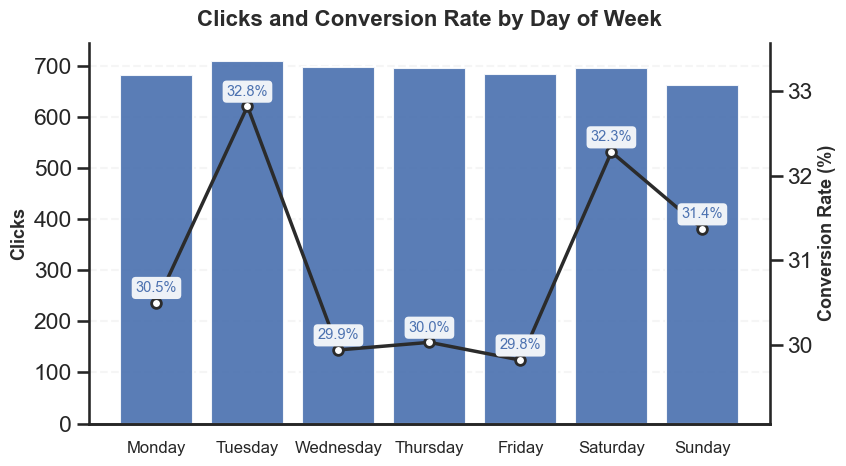

In [4]:
# --- Load + enforce weekday order ---
weekday_conversion = pd.read_csv("../results/conversion_by_day_of_week.csv")

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_conversion["day_of_week"] = pd.Categorical(
    weekday_conversion["day_of_week"],
    categories=weekday_order,
    ordered=True
)

weekday_conversion = weekday_conversion.sort_values("day_of_week")


fig, ax1 = plt.subplots(figsize=(8.8, 5.0))

# --- Style system (match your other charts) ---
primary = "#4C72B0"
text_dark = "#2B2B2B"
text_muted = "#6B6B6B"
pill_bg = "#EEF2F7"

# --- Bars: Clicks ---
bars = ax1.bar(
    weekday_conversion["day_of_week"],
    weekday_conversion["total_clicks"],
    color=primary,
    alpha=0.92
)

# Clean up ax1
ax1.set_ylabel("Clicks", fontsize=13, fontweight="bold", color=text_dark)
ax1.set_xlabel("")
ax1.grid(axis="y", linestyle="--", alpha=0.18)
ax1.grid(axis="x", visible=False)
ax1.tick_params(axis='x', labelsize=12)

# Subtle spine cleanup
sns.despine(ax=ax1, right=False, top=True)

# --- Line: Conversion Rate (2nd axis) ---
ax2 = ax1.twinx()

line_color = "#2B2B2B"   # dark neutral (matches text_dark)

ax2.plot(
    weekday_conversion["day_of_week"],
    weekday_conversion["conversion_rate_percent"],
    marker="o",
    markersize=7,
    markerfacecolor="white",     # makes marker pop
    markeredgewidth=2,
    linewidth=2.5,
    color=line_color,
    zorder=3                     # ensures line renders above bars
)

ax2.set_ylabel("Conversion Rate (%)",
               fontsize=13,
               fontweight="bold",
               color=text_dark)

ax2.grid(False)
sns.despine(ax=ax2, left=True, top=True)


# Set tighter y-limits with padding (instead of hardcoding)
cr_min = weekday_conversion["conversion_rate_percent"].min()
cr_max = weekday_conversion["conversion_rate_percent"].max()
pad = max(0.6, (cr_max - cr_min) * 0.25)
ax2.set_ylim(cr_min - pad, cr_max + pad)

# --- Value pills for conversion rate points ---
x = weekday_conversion["day_of_week"].tolist()
y = weekday_conversion["conversion_rate_percent"].tolist()
for xi, yi in zip(x, y):
    ax2.text(
        xi, yi + (pad * 0.12),
        f"{yi:.1f}%",
        ha="center", va="bottom",
        fontsize=10.5,
        color=primary,
        bbox=dict(boxstyle="round,pad=0.28", facecolor=pill_bg, edgecolor="none")
    )

# --- Title ---
ax1.set_title("Clicks and Conversion Rate by Day of Week",
              fontsize=16, fontweight="bold", pad=12, color=text_dark)

plt.tight_layout()
plt.show()

fig.savefig("../figures/clicks_and_cvr_by_dayofweek.png", dpi=300, bbox_inches="tight")


> Conversion rates peak on Tuesday (32.82%) and Saturday (32.28%), while click volume is fairly consistent across the week